In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('titanic.csv')


In [7]:
df.head()

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   sex          891 non-null    object 
 4   age          714 non-null    float64
 5   sibsp        891 non-null    int64  
 6   parch        891 non-null    int64  
 7   fare         891 non-null    float64
 8   embarked     889 non-null    object 
 9   class        891 non-null    object 
 10  who          891 non-null    object 
 11  adult_male   891 non-null    bool   
 12  deck         203 non-null    object 
 13  embark_town  889 non-null    object 
 14  alive        891 non-null    object 
 15  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(5), object(7)
memory usage: 99.3+ KB


,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,445.000000,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,222.500000,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,445.000000,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,667.500000,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# missing values

missing_counts=df.isna().sum().sort_values(ascending=False)
print(missing_counts)
missing_rows=df[df.isna().any(axis=1)]
print(missing_rows)
missing_rows_indexes=missing_rows.index
print(missing_rows_indexes)

nan_indices = {}

for col in df.columns:
    indices = df.index[df[col].isna()].tolist()
    
    if len(indices) > 0:
        nan_indices[col] = indices


deck           688
age            177
embarked         2
embark_town      2
sex              0
Unnamed: 0       0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64
     Unnamed: 0  survived  pclass     sex   age  sibsp  parch     fare  \
0             0         0       3    male  22.0      1      0   7.2500   
2             2         1       3  female  26.0      0      0   7.9250   
4             4         0       3    male  35.0      0      0   8.0500   
5             5         0       3    male   NaN      0      0   8.4583   
7             7         0       3    male   2.0      3      1  21.0750   
..          ...       ...     ...     ...   ...    ...    ...      ...   
884         884         0       3    male  25.0      0      0   7.0500   
885         885         0       3  female  39.0      0      5  29.1250   
886         886  

In [10]:
#ِ Duplicated Values
duplicate_count=df.duplicated().sum()
print(duplicate_count)
duplicate_rows=df[df.duplicated()]
print(duplicate_rows)
id_column_duplicated_count=df["Unnamed: 0"].duplicated().sum()
print(id_column_duplicated_count)

0
Empty DataFrame
Columns: [Unnamed: 0, survived, pclass, sex, age, sibsp, parch, fare, embarked, class, who, adult_male, deck, embark_town, alive, alone]
Index: []
0


In [11]:
# Out of Range

for col in df.columns:
    if df[col].dtype == "int64" or df[col].dtype == "float64":
        print("column ", col,"max is:" ,df[col].max() , " and min is: " ,df[col].min()) 

column  Unnamed: 0 max is: 890  and min is:  0
column  survived max is: 1  and min is:  0
column  pclass max is: 3  and min is:  1
column  age max is: 80.0  and min is:  0.42
column  sibsp max is: 8  and min is:  0
column  parch max is: 6  and min is:  0
column  fare max is: 512.3292  and min is:  0.0


181.2844937601173


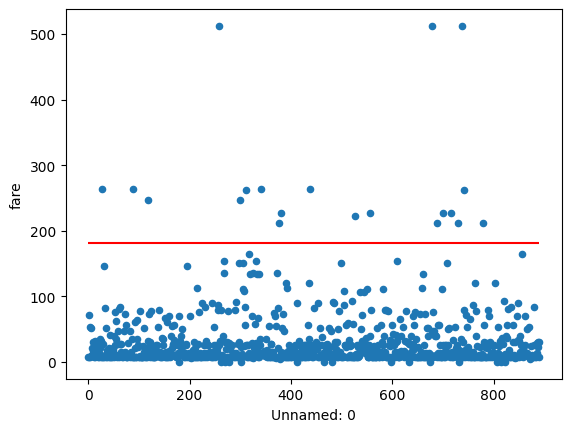

In [12]:
fare_upper_range= df["fare"].mean()+3*df['fare'].std()
print(fare_upper_range)
df.plot.scatter(x='Unnamed: 0',y='fare')
plt.hlines(y=fare_upper_range,xmin=0,xmax=890,colors='red')
plt.show()


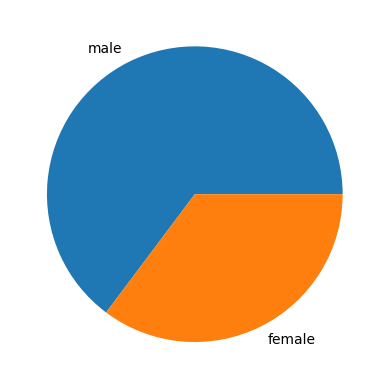

In [13]:
male_count=0
for i in df['sex']:
    if i=='male':
        male_count=male_count+1

female_count=len(df['sex'])-male_count

sizes=[male_count,female_count]
labels=['male','female']

plt.pie(sizes,labels=labels,)
plt.show()